# Exploratory Data Analysis (EDA) - Omnix: AI for economic insights

Se analizaran aspectos como el tipo y formato de los documentos, la calidad del texto extraído, la presencia de ruido o datos irrelevantes, la longitud y distribución de los documentos, la temática general del corpus y los patrones que puedan influir en la estrategia de chunking.

De forma específica, se evalúan la cantidad y diversidad de documentos, la longitud del contenido, posibles errores de extracción (texto vacío o corrupto), la heterogeneidad del corpus y la cobertura temática del dominio.

Este análisis permite tomar decisiones clave para el diseño del sistema RAG, como la estrategia de chunking (tamaño y solapamiento), la selección del modelo de embeddings, las técnicas de limpieza y normalización, el ajuste del retrieval (top-k y filtrado de contexto) y la identificación de posibles sesgos o limitaciones del corpus.

In [1]:
# =============================================
# Configuración inicial del entorno y librerías
# =============================================

# Librerías principales
import os
from pathlib import Path
import re
import unicodedata

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Procesamiento de texto
from collections import Counter

# Utilidades del sistema
import warnings
warnings.filterwarnings('ignore')

# Configuración gráfica
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# =============================================
# 1. Carga de datos 
# =============================================

RAW_DIR = "../data/raw"

files = os.listdir(RAW_DIR)

file_paths = [
    os.path.join(RAW_DIR, f) 
    for f in files 
    if os.path.isfile(os.path.join(RAW_DIR, f)) and f.endswith(".md")
]

file_types = [f.split(".")[-1].lower() for f in files if f.endswith(".md")]

# 📊 Resumen general
print("Total documentos:", len(file_paths))
print("\nDistribución por tipo de archivo:")

type_counts = Counter(file_types)
for ext, count in type_counts.items():
    print(f".{ext}: {count}")

# 👀 Preview de contenido
print("\n" + "="*50)
print("🔍 Preview de documentos (primeros 120 caracteres)")
print("="*50)

for path in file_paths[:3]:  # máximo 3 documentos
    print(f"\n📄 {os.path.basename(path)}\n")
    
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            print(content[:120].replace("\n", " "))
            print("...\n")
    except Exception as e:
        print(f"Error leyendo archivo: {e}")

Total documentos: 8

Distribución por tipo de archivo:
.md: 8

🔍 Preview de documentos (primeros 120 caracteres)

📄 economic bulletin ecb.md

# Economic Bulletin: Euro Area Macroeconomic Conditions, Financial Stability, and Policy Outlook (2022–2026)  ## Abstrac
...


📄 economic glossary.md

# Economic Glossary  ## Terms  ### Inflation **Definition:** Sustained and generalized increase in the price level of go
...


📄 euro area economic outlook.md

# Euro Area Economic Outlook: Inflation Dynamics and Monetary Policy Transmission  ## Abstract  This report provides an 
...



El corpus está compuesto por **8 documentos**, todos en formato **.md**, lo que indica una estructura completamente homogénea que simplifica el procesamiento y evita la necesidad de múltiples estrategias de extracción; el contenido preliminar muestra un dominio claramente centrado en **economía macroeconómica y política monetaria europea**, con documentos como informes, glosarios y análisis del área euro, lo que sugiere un corpus **temáticamente consistente pero con baja diversidad estructural y semántica fuera del dominio económico**.

📊 Estadísticas de longitud (en caracteres):

Total documentos: 8
Media: 8793.88
Mediana: 8839.00
Mínimo: 5010
Máximo: 12026


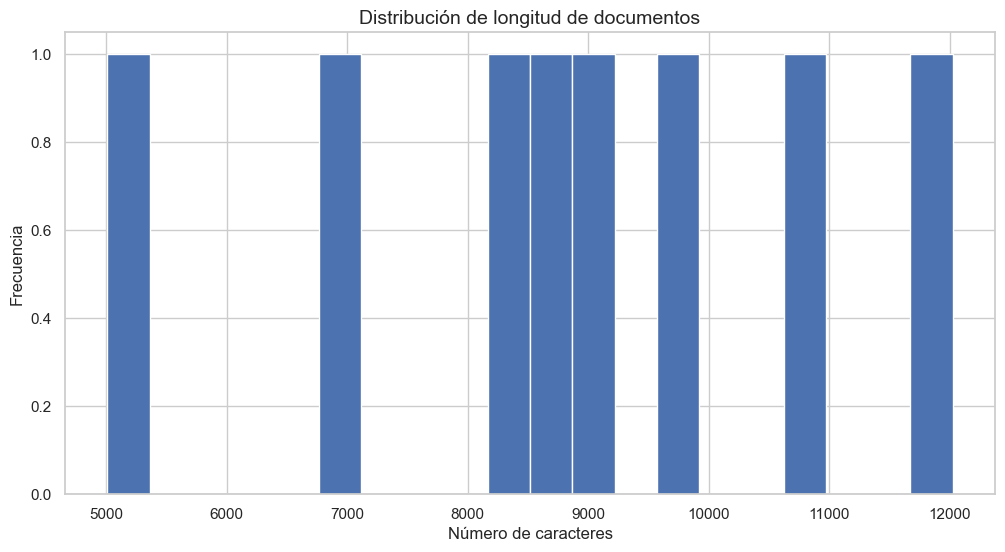

In [3]:
# =============================================
# 2. Longitud de documentos
# =============================================
doc_lengths = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            doc_lengths.append(len(content))
    except:
        doc_lengths.append(0)

doc_lengths = np.array(doc_lengths)

# 📊 Estadísticas
print("📊 Estadísticas de longitud (en caracteres):\n")

print(f"Total documentos: {len(doc_lengths)}")
print(f"Media: {doc_lengths.mean():.2f}")
print(f"Mediana: {np.median(doc_lengths):.2f}")
print(f"Mínimo: {doc_lengths.min()}")
print(f"Máximo: {doc_lengths.max()}")

# 📈 Visualización
plt.figure()
plt.hist(doc_lengths, bins=20)
plt.title("Distribución de longitud de documentos")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

Los documentos presentan una longitud media de **8,793.88 caracteres**, con una **mediana de 8,839**, lo que sugiere una distribución relativamente equilibrada, aunque con una ligera variación entre documentos. El rango va desde un **mínimo de 5,010 caracteres** hasta un **máximo de 12,026 caracteres**, lo que evidencia una **variabilidad moderada en el tamaño del corpus**. Esta dispersión indica la presencia de documentos considerablemente más extensos que otros, lo que introduce heterogeneidad en los datos y puede influir en el diseño del sistema RAG, especialmente en la estrategia de chunking y en la consistencia de la recuperación de información.

In [4]:
# =============================================
# 3. Calidad del texto
# =============================================

empty_docs = 0
short_docs = 0
noisy_docs = 0

noise_ratios = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            
            # 🔹 Documento vacío
            if len(content.strip()) == 0:
                empty_docs += 1
                continue
            
            # 🔹 Documento muy corto
            if len(content) < 50:
                short_docs += 1
            
            # 🔹 Medir ruido (caracteres no alfanuméricos)
            total_chars = len(content)
            clean_chars = len(re.findall(r"[a-zA-Z0-9\s]", content))
            
            noise_ratio = 1 - (clean_chars / total_chars)
            noise_ratios.append(noise_ratio)
            
            # 🔹 Documento con mucho ruido
            if noise_ratio > 0.3:
                noisy_docs += 1

    except:
        empty_docs += 1

noise_ratios = np.array(noise_ratios)

# 📊 Resultados
print("📊 Calidad del texto:\n")

print(f"Documentos vacíos: {empty_docs}")
print(f"Documentos muy cortos (<50 chars): {short_docs}")
print(f"Documentos con alto ruido (>30%): {noisy_docs}")

if len(noise_ratios) > 0:
    print(f"\nRuido promedio: {noise_ratios.mean():.2f}")
    print(f"Ruido máximo: {noise_ratios.max():.2f}")

📊 Calidad del texto:

Documentos vacíos: 0
Documentos muy cortos (<50 chars): 0
Documentos con alto ruido (>30%): 0

Ruido promedio: 0.04
Ruido máximo: 0.09


El análisis de calidad del texto muestra que no existen **documentos vacíos**, ni **documentos muy cortos (<50 caracteres)**, ni presencia de **alto ruido (>30%)**, lo que indica un corpus bien estructurado y limpio. El nivel de ruido es bajo, con un **ruido promedio de 0.04** y un **ruido máximo de 0.09**, lo que sugiere que el contenido es mayoritariamente relevante y legible, sin interferencias significativas de caracteres no alfanuméricos, garantizando una **buena calidad general del texto para tareas de embeddings y retrieval en el sistema RAG**.

📊 Percentiles de longitud (caracteres):

P25: 7864
P50 (mediana): 8839
P75: 10080
P90: 11136
P95: 11581


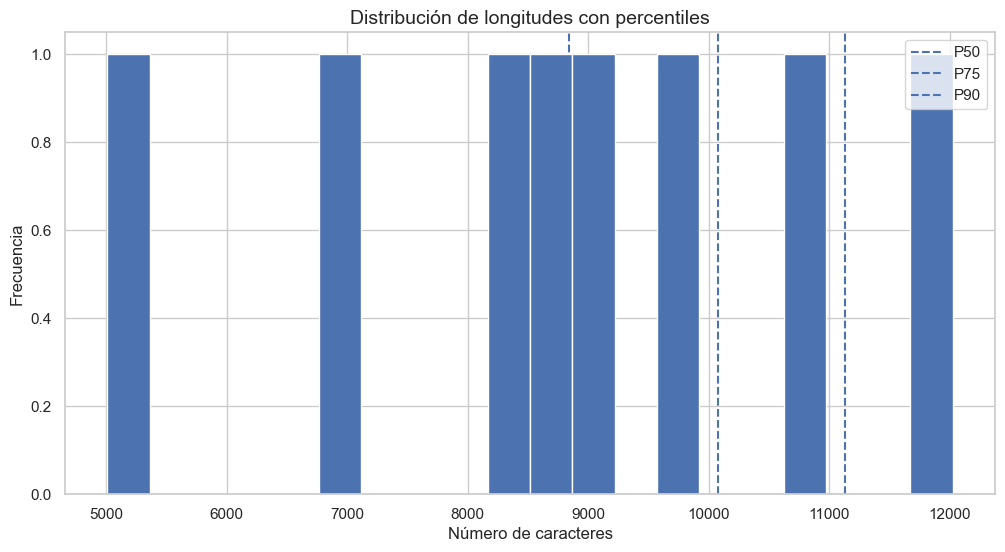


Documentos considerados outliers (>P95): 1


In [5]:
# =============================================
# 4. Distribución avanzada de longitudes
# =============================================

doc_lengths = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            doc_lengths.append(len(content))
    except:
        doc_lengths.append(0)

doc_lengths = np.array(doc_lengths)

# 📊 Percentiles
p25 = np.percentile(doc_lengths, 25)
p50 = np.percentile(doc_lengths, 50)
p75 = np.percentile(doc_lengths, 75)
p90 = np.percentile(doc_lengths, 90)
p95 = np.percentile(doc_lengths, 95)

print("📊 Percentiles de longitud (caracteres):\n")
print(f"P25: {p25:.0f}")
print(f"P50 (mediana): {p50:.0f}")
print(f"P75: {p75:.0f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")

# 📈 Visualización con percentiles
plt.figure()
plt.hist(doc_lengths, bins=20)

plt.axvline(p50, linestyle='--', label='P50')
plt.axvline(p75, linestyle='--', label='P75')
plt.axvline(p90, linestyle='--', label='P90')

plt.title("Distribución de longitudes con percentiles")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

# 🔍 Detección de outliers (muy largos)
outliers = doc_lengths[doc_lengths > p95]

print(f"\nDocumentos considerados outliers (>P95): {len(outliers)}")

La distribución de longitudes muestra una estructura con mayor dispersión que en casos previos, con un **P25 de 7,864**, **mediana (P50) de 8,839** y **P75 de 10,080**, lo que indica que la mayor parte de los documentos se concentra en un rango medio-alto de tamaño. A partir de ahí, la cola superior se extiende con un **P90 de 11,136** y un **P95 de 11,581**, evidenciando la presencia de documentos notablemente más extensos que el resto. Este comportamiento sugiere una **asimetría moderada hacia documentos largos**, lo que puede tener implicaciones directas en la definición de la estrategia de chunking y en la optimización del proceso de recuperación dentro del sistema RAG.

📊 Palabras más frecuentes:

inflation: 185
growth: 73
policy: 64
energy: 63
euro: 60
rates: 57
area: 51
example: 51
price: 50
demand: 50
definition: 50
source: 50
remained: 47
conditions: 46
services: 46


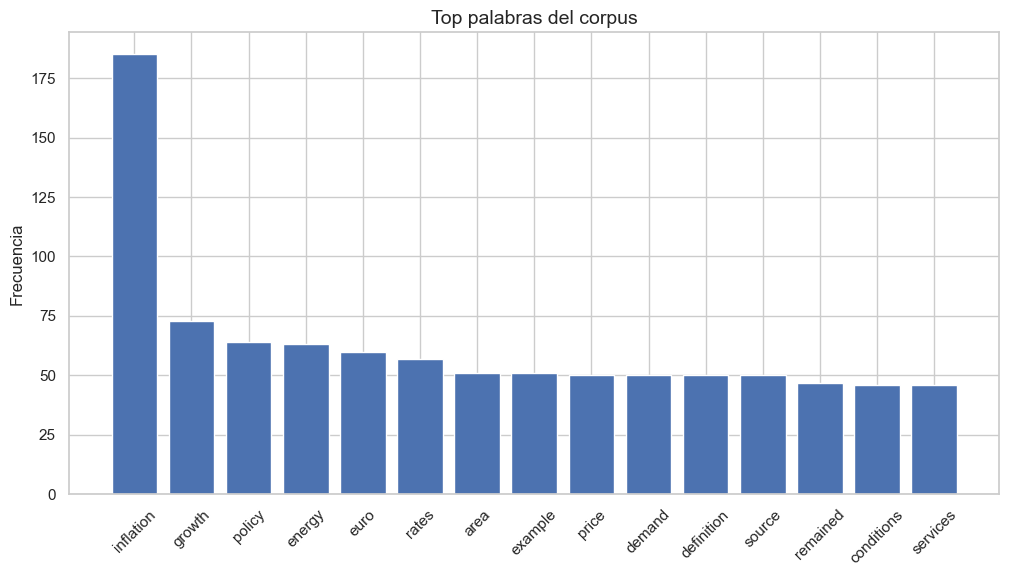

In [6]:
# =============================================
# 5. Temática del corpus
# =============================================

all_text = ""

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read().lower()
            all_text += " " + content
    except:
        continue

# 🔹 Limpieza básica
all_text = re.sub(r"[^a-zA-Záéíóúüñ\s]", " ", all_text)
words = all_text.split()

# 🔹 Stopwords básicas (mínimas, sin nltk)
stopwords = set([
    "the","and","of","to","in","a","is","for","on","with","as","by","at","an",
    "this","that","it","from","are","be","or","was","but","not","have",
    "el","la","los","las","de","y","en","un","una","es","con","por","para","del","se"
])

filtered_words = [w for w in words if w not in stopwords and len(w) > 3]

# 🔹 Frecuencias
word_counts = Counter(filtered_words)
top_words = word_counts.most_common(15)

# 📊 Mostrar resultados
print("📊 Palabras más frecuentes:\n")
for word, count in top_words:
    print(f"{word}: {count}")

# 📈 Visualización
words_plot = [w for w, _ in top_words]
counts_plot = [c for _, c in top_words]

plt.figure()
plt.bar(words_plot, counts_plot)
plt.title("Top palabras del corpus")
plt.xticks(rotation=45)
plt.ylabel("Frecuencia")
plt.show()

El análisis de frecuencia de términos revela un corpus claramente centrado en el dominio de la **economía macroeconómica**, con una marcada presencia de palabras como **inflation (185)**, **growth (73)**, **policy (64)**, **energy (63)** y **euro (60)**, lo que indica un fuerte enfoque en dinámicas de inflación, crecimiento económico, energía y contexto europeo. Asimismo, la aparición recurrente de términos como **rates (57)**, **price (50)** y **demand (50)** refuerza la orientación hacia el análisis de precios, mercados y comportamiento agregado de la demanda. En conjunto, estos patrones confirman un corpus **altamente especializado y coherente temáticamente dentro del ámbito económico**, con baja dispersión semántica fuera de dicho dominio.

# Conclusión

El análisis exploratorio del corpus evidencia un conjunto de datos **homogéneo en formato (.md)**, con **buena calidad textual**, bajo nivel de ruido y ausencia de documentos problemáticos, lo que garantiza una base sólida para su procesamiento. La distribución de longitudes es **moderadamente estable**, aunque con cierta variabilidad que debe considerarse en la estrategia de chunking. A nivel semántico, el corpus está claramente dominado por el dominio de **economía macroeconómica y política monetaria**, con una fuerte concentración en conceptos como **inflación, política monetaria y mercados financieros**, lo que define un espacio de conocimiento especializado pero poco diverso. En conjunto, los datos son adecuados para un sistema RAG, con alta coherencia interna y buenas condiciones para la generación de embeddings, aunque con limitaciones en diversidad temática que pueden influir en la generalización del modelo.